### Blok 1: Inisialisasi Environment & Library

In [22]:
# ==============================================================================
# 1. INITIALIZATION & LIBRARY IMPORT
# ==============================================================================
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Aturan visualisasi agar serasi untuk standar paper ilmiah (IEEE/Springer)
# Tanda kurung () pada plt.style.available telah dihapus
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
sns.set_context("paper", font_scale=1.2)

import warnings
warnings.filterwarnings('ignore')

print("Environment berhasil disiapkan. Siap menganalisis dataset.")

Environment berhasil disiapkan. Siap menganalisis dataset.


### Blok 2: Memuat Dataset Mentah (Raw Data)

In [23]:
# ==============================================================================
# 2. DATA LOADING & METADATA INSPECTION
# ==============================================================================
# Path dataset disesuaikan dengan struktur folder baru Anda
DATASET_PATH = "../dataset/raw/final_dataset_with_all_features_v3.1.csv"

if os.path.exists(DATASET_PATH):
    df = pd.read_csv(DATASET_PATH)
    print(f"✅ Dataset berhasil dimuat!")
    print(f"Total Baris (Sampel): {df.shape[0]:,}")
    print(f"Total Kolom (Fitur): {df.shape[1]}")
else:
    print(f"❌ File tidak ditemukan di: {DATASET_PATH}. Pastikan file csv sudah diletakkan di sana.")

# Tampilkan informasi tipe data dan memori
print("\n--- Ringkasan Struktur Data ---")
print(df.info())

✅ Dataset berhasil dimuat!
Total Baris (Sampel): 651,191
Total Kolom (Fitur): 64

--- Ringkasan Struktur Data ---
<class 'pandas.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 64 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   url                           651191 non-null  str    
 1   type                          651191 non-null  str    
 2   label                         651191 non-null  int64  
 3   url_len                       651191 non-null  int64  
 4   @                             651191 non-null  int64  
 5   ?                             651191 non-null  int64  
 6   -                             651191 non-null  int64  
 7   =                             651191 non-null  int64  
 8   .                             651191 non-null  int64  
 9   #                             651191 non-null  int64  
 10  %                             651191 non-null  int64  
 11  +

### Blok 3: Verifikasi Kolom String Teks URL (Krusial untuk 1D-CNN)

In [24]:
# ==============================================================================
# 3. CORE COMPLIANCE CHECK (URL STRING VERIFICATION)
# ==============================================================================
# TODO: Sesuaikan string 'url' di bawah dengan nama kolom teks URL yang sebenarnya di dataset Kaggle Anda
URL_COLUMN_NAME = 'url' 

if URL_COLUMN_NAME in df.columns:
    print(f"✅ Kolom '{URL_COLUMN_NAME}' ditemukan.")
    print("\nSampel String URL Utuh:")
    print(df[URL_COLUMN_NAME].head(5))
    
    # Validasi tipe data kolom URL
    if df[URL_COLUMN_NAME].dtype == 'object':
        print("\nStatus Tipe Data: COMPLIANT (Siap untuk tokenisasi tingkat karakter / 1D-CNN).")
    else:
        print("\nPeringatan: Tipe data bukan objek/string. Perlu konversi tipe data.")
else:
    print(f"❌ Kolom bernama '{URL_COLUMN_NAME}' TIDAK ditemukan.")
    print(f"Kolom yang tersedia adalah: {df.columns.tolist()}")

✅ Kolom 'url' ditemukan.

Sampel String URL Utuh:
0                                     br-icloud.com.br
1                  mp3raid.com/music/krizz_kaliko.html
2                      bopsecrets.org/rexroth/cr/1.htm
3    http://garage-pirenne.be/index.php?option=com_...
4    http://adventure-nicaragua.net/index.php?optio...
Name: url, dtype: str

Peringatan: Tipe data bukan objek/string. Perlu konversi tipe data.


### Blok 4: Analisis Empiris Ketidakseimbangan Kelas (Class Imbalance)

--- Distribusi Kelas ---
Kelas '0': 428,103 sampel (65.74%)
Kelas '1': 96,457 sampel (14.81%)
Kelas '2': 94,111 sampel (14.45%)
Kelas '3': 32,520 sampel (4.99%)

Imbalance Ratio (IR): 13.16
Status: DATASET ALAMI IMBALANCE. Diperlukan penanganan pada fase Preprocessing.


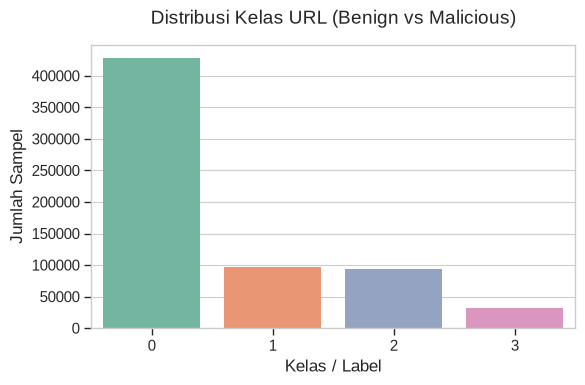

In [25]:
# ==============================================================================
# 4. EMPIRICAL CLASS DISTRIBUTION ANALYSIS
# ==============================================================================
# TODO: Sesuaikan 'label' dengan nama kolom target/kelas di dataset Anda (misal: 'label', 'status', 'type')
LABEL_COLUMN_NAME = 'label' 

if LABEL_COLUMN_NAME in df.columns:
    class_counts = df[LABEL_COLUMN_NAME].value_counts()
    class_percentages = df[LABEL_COLUMN_NAME].value_counts(normalize=True) * 100
    
    print("--- Distribusi Kelas ---")
    for idx in class_counts.index:
        print(f"Kelas '{idx}': {class_counts[idx]:,} sampel ({class_percentages[idx]:.2f}%)")
    
    # Kalkulasi Imbalance Ratio (IR) untuk argumen di Laporan Ilmiah S2
    ir = class_counts.max() / class_counts.min()
    print(f"\nImbalance Ratio (IR): {ir:.2f}")
    if ir > 1.5:
        print("Status: DATASET ALAMI IMBALANCE. Diperlukan penanganan pada fase Preprocessing.")
    else:
        print("Status: DATASET SEIMBANG.")
        
    # Visualisasi Distribusi Kelas untuk Dokumen Bab Laporan
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=LABEL_COLUMN_NAME, palette='Set2')
    plt.title('Distribusi Kelas URL (Benign vs Malicious)', fontsize=14, pad=15)
    plt.xlabel('Kelas / Label', fontsize=12)
    plt.ylabel('Jumlah Sampel', fontsize=12)
    plt.tight_layout()
    plt.savefig('../reports/figures/01_class_distribution.png', dpi=300)
    plt.show()
else:
    print(f"❌ Kolom target '{LABEL_COLUMN_NAME}' tidak ditemukan.")

### Blok 5: Transformasi Biner (ANALISIS AFTER STATE)

--- Menjalankan Transformasi Skema Multi-Kelas ke Biner ---

--- Distribusi Kelas Setelah Transformasi Biner ---
Kelas 0 (Benign)   : 428,103 sampel (65.74%)
Kelas 1 (Malicious): 223,088 sampel (34.26%)
Imbalance Ratio (IR) Baru: 1.92
Status: DATASET AMAN (Mild Imbalance). Menyembuhkan model dari Accuracy Paradox!


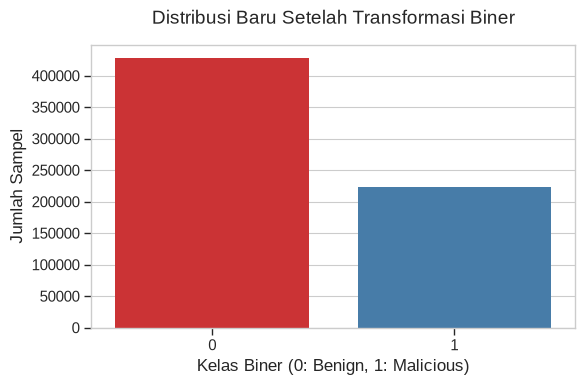

In [26]:
# ==============================================================================
# 5. BINARY TARGET TRANSFORMATION & AFTER-STATE ANALYSIS
# ==============================================================================
# TODO: Pastikan nama 'label' sesuai dengan kolom target di dataset Anda
LABEL_COLUMN_NAME = 'label'

print("--- Menjalankan Transformasi Skema Multi-Kelas ke Biner ---")
# Pemetaan: Kelas 0 tetap 0 (Benign), selain itu (1, 2, 3) digabung menjadi 1 (Malicious)
df['label'] = df[LABEL_COLUMN_NAME].apply(lambda x: 0 if x == 0 else 1)

# Hitung ulang distribusi biner
binary_counts = df['label'].value_counts()
binary_percentages = df['label'].value_counts(normalize=True) * 100
new_ir = binary_counts[0] / binary_counts[1]

print("\n--- Distribusi Kelas Setelah Transformasi Biner ---")
print(f"Kelas 0 (Benign)   : {binary_counts[0]:,} sampel ({binary_percentages[0]:.2f}%)")
print(f"Kelas 1 (Malicious): {binary_counts[1]:,} sampel ({binary_percentages[1]:.2f}%)")
print(f"Imbalance Ratio (IR) Baru: {new_ir:.2f}")

if new_ir < 2.0:
    print("Status: DATASET AMAN (Mild Imbalance). Menyembuhkan model dari Accuracy Paradox!")
else:
    print("Status: Dataset masih membutuhkan perhatian pembobotan.")

# Visualisasi distribusi biner untuk laporan V2
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label', palette='Set1')
plt.title('Distribusi Baru Setelah Transformasi Biner', fontsize=14, pad=15)
plt.xlabel('Kelas Biner (0: Benign, 1: Malicious)', fontsize=12)
plt.ylabel('Jumlah Sampel', fontsize=12)
plt.tight_layout()
plt.savefig('../reports/figures/01_binary_class_distribution.png', dpi=300)
plt.show()

### Blok 6: Analisis Duplikasi dan Data Noise

In [27]:
# ==============================================================================
# 6. NOISE AND DUPLICATE ANALYSIS
# ==============================================================================
missing_values = df.isnull().sum()
total_missing = missing_values.sum()

print("--- Analisis Missing Values ---")
if total_missing > 0:
    print(missing_values[missing_values > 0])
else:
    print("Sempurna! Tidak ada missing values di dalam dataset.")

print("\n--- Analisis Duplikasi Teks URL ---")
if URL_COLUMN_NAME in df.columns:
    total_duplicates = df.duplicated(subset=[URL_COLUMN_NAME]).sum()
    print(f"Jumlah baris dengan URL duplikat: {total_duplicates:,} ({ (total_duplicates/len(df))*100 :.2f}%)")
    print("Rekomendasi: Lakukan drop_duplicates pada tahap pipeline cleaning untuk mencegah data leakage.")

--- Analisis Missing Values ---
domain    12223
dtype: int64

--- Analisis Duplikasi Teks URL ---
Jumlah baris dengan URL duplikat: 11,110 (1.71%)
Rekomendasi: Lakukan drop_duplicates pada tahap pipeline cleaning untuk mencegah data leakage.


### Blok 7: Profiling Karakteristik Panjang Teks URL

--- Deskripsi Statistik Panjang URL ---
count    651191.000000
mean         59.375960
std          44.521589
min           1.000000
25%          31.000000
50%          47.000000
75%          76.000000
max        2175.000000
Name: url_length, dtype: float64


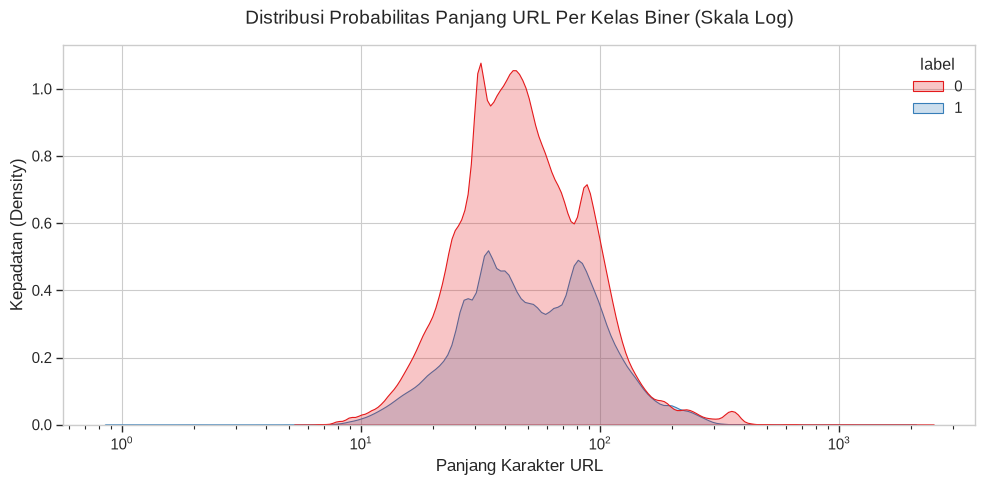

In [28]:
# ==============================================================================
# 7. INITIAL LEXICAL PROPERTY PROFILING (URL LENGTH DISTRIBUTION)
# ==============================================================================
if URL_COLUMN_NAME in df.columns:
    # Ekstraksi properti panjang teks URL
    df['url_length'] = df[URL_COLUMN_NAME].astype(str).apply(len)
    
    print("--- Deskripsi Statistik Panjang URL ---")
    print(df['url_length'].describe())
    
    # Visualisasi Distribusi Panjang URL berdasarkan Kelas Biner
    plt.figure(figsize=(10, 5))
    sns.kdeplot(data=df, x='url_length', hue='label', shade=True, log_scale=True, palette='Set1')
    plt.title('Distribusi Probabilitas Panjang URL Per Kelas Biner (Skala Log)', fontsize=14, pad=15)
    plt.xlabel('Panjang Karakter URL', fontsize=12)
    plt.ylabel('Kepadatan (Density)', fontsize=12)
    plt.tight_layout()
    plt.savefig('../reports/figures/01_url_length_density_binary.png', dpi=300)
    plt.show()

### Blok 8: Pipeline Pembersihan Data

In [29]:
# ==============================================================================
# 8. INITIAL CLEANING & PREPROCESSING PIPELINE
# ==============================================================================
print(f"Ukuran dataset sebelum dibersihkan: {df.shape}")

# 1. Drop Duplikat Teks URL untuk mencegah Data Leakage
df.drop_duplicates(subset=[URL_COLUMN_NAME], inplace=True)

# 2. Filter out data noise (URL yang terlalu pendek / tidak valid)
df = df[df['url_length'] >= 10]

# 3. Imputasi missing values pada kolom domain
if 'domain' in df.columns:
    df['domain'].fillna('ip_address_or_unknown', inplace=True)

print(f"Ukuran dataset setelah pembersihan awal: {df.shape}")

Ukuran dataset sebelum dibersihkan: (651191, 65)
Ukuran dataset setelah pembersihan awal: (638564, 65)


### Blok 9: Checkpoint Ekspor Data

In [32]:
# ==============================================================================
# 9. EXPORT CLEANED BINARY DATASET FOR NEXT PHASE
# ==============================================================================
OUTPUT_PROCESSED_PATH = "../dataset/processed/cleaned_binary_malicious_urls.csv"

# Simpan data bersih siap pakai ke folder processed
df.to_csv(OUTPUT_PROCESSED_PATH, index=False)

print(f"🎉 Tahap Data Understanding & Preprocessing SELESAI!")
print(f"Dataset Biner yang telah bersih berhasil diekspor di: {OUTPUT_PROCESSED_PATH}")

🎉 Tahap Data Understanding & Preprocessing SELESAI!
Dataset Biner yang telah bersih berhasil diekspor di: ../dataset/processed/cleaned_binary_malicious_urls.csv
